# **🚢 Titanic Survival Prediction Using Machine Learning**

**Project Type:**
Data Science Internship Project

**Dataset:**
Titanic Dataset

**Author:**
Avi Patel

---

# 📌 Problem Statement

This project aims to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster based on features such as age, gender, passenger class, and fare. The goal is to analyze passenger data and identify the factors that influenced survival.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# **Load Dataset**

**Google Colab**

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Local PC**

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Dataset Overview**

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Missing Values**

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Statistical Summary**

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Data Cleaning**

**Age**

In [13]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

**Embarked**

In [14]:
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

**Cabin**

In [15]:
df.drop(
    'Cabin',
    axis=1,
    inplace=True
)

**Verify**

In [16]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Survival Distribution**

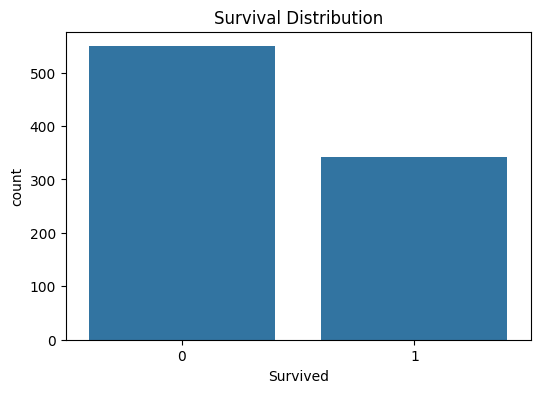

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survival Distribution")

plt.show()

# **Gender Distribution**

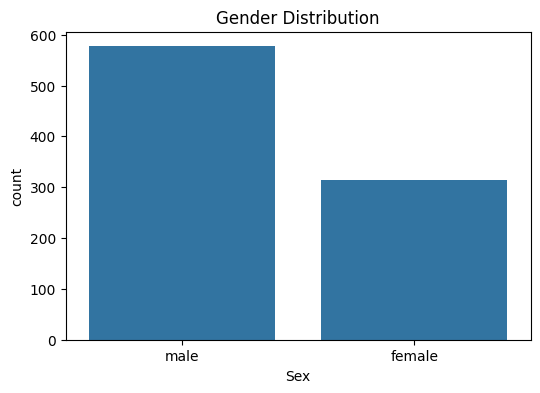

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    data=df
)

plt.title("Gender Distribution")

plt.show()

# **Survival by Gender**

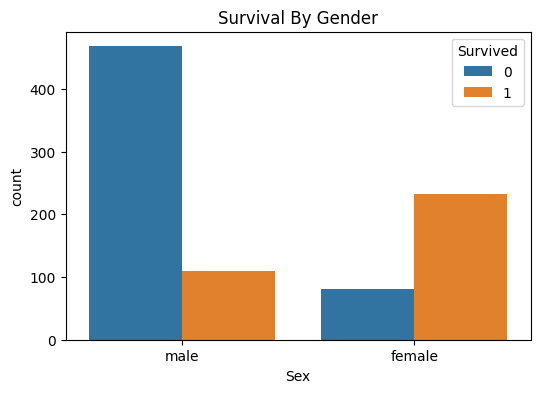

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival By Gender")

plt.show()

# **Passenger Class Distribution**

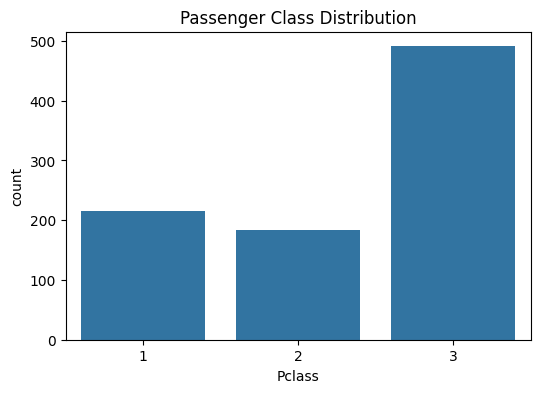

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    data=df
)

plt.title("Passenger Class Distribution")

plt.show()

# **Survival Rate by Passenger Class**

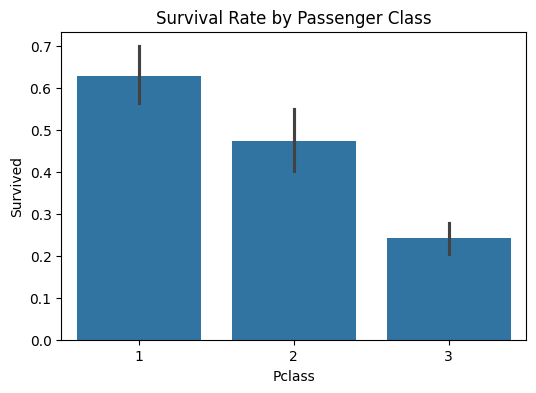

In [33]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Passenger Class")

plt.show()

# **Age Distribution**

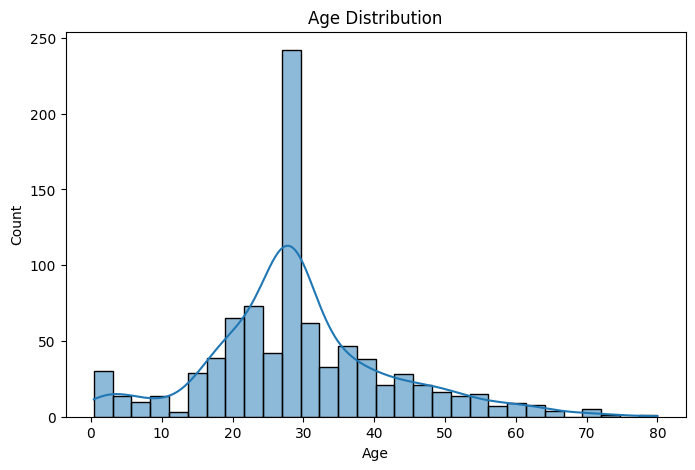

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

# **Fare Distribution**

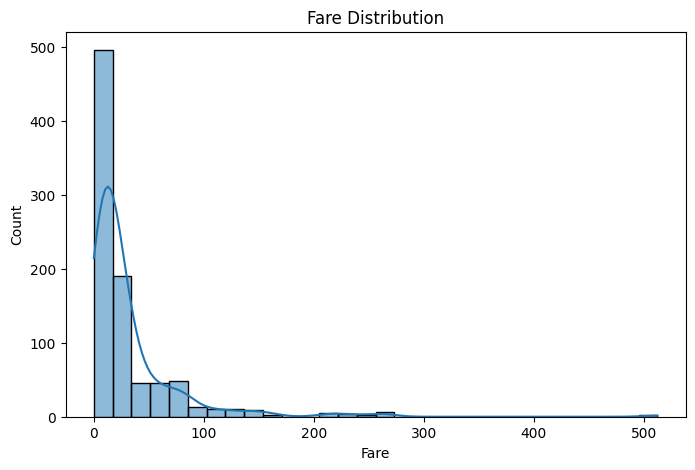

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Fare'],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")

plt.show()

# **Correlation Heatmap**

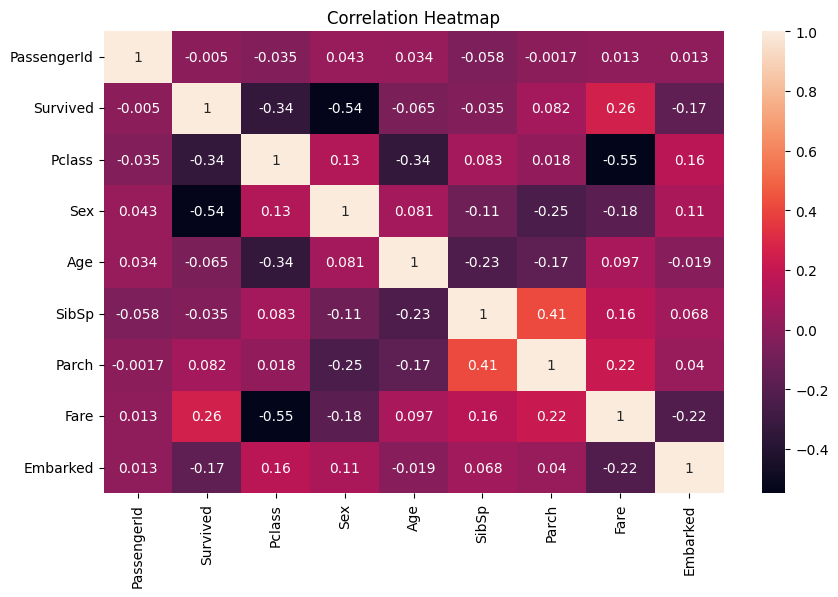

In [21]:
temp_df = df.copy()

le = LabelEncoder()

temp_df['Sex'] = le.fit_transform(
    temp_df['Sex']
)

temp_df['Embarked'] = le.fit_transform(
    temp_df['Embarked']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    temp_df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# **Feature Engineering**

In [22]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(
    df['Sex']
)

df['Embarked'] = encoder.fit_transform(
    df['Embarked']
)

# **Drop Unnecessary Columns**

In [23]:
df.drop(
    ['PassengerId',
     'Name',
     'Ticket'],
    axis=1,
    inplace=True
)

# **Features and Target**

In [24]:
X = df.drop(
    'Survived',
    axis=1
)

y = df['Survived']

# **Train Test Split**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Model Training**

**Logistic Regression**

In [39]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 81.01 %


**Decision Tree**

In [41]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy*100,2),
    "%"
)

Decision Tree Accuracy: 78.21 %


**Random Forest**

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Imports Successful")

Imports Successful


In [45]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 82.12 %


# **Model Comparison table**

In [46]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.782123
2,Random Forest,0.821229


# **Model Comparison Graph**

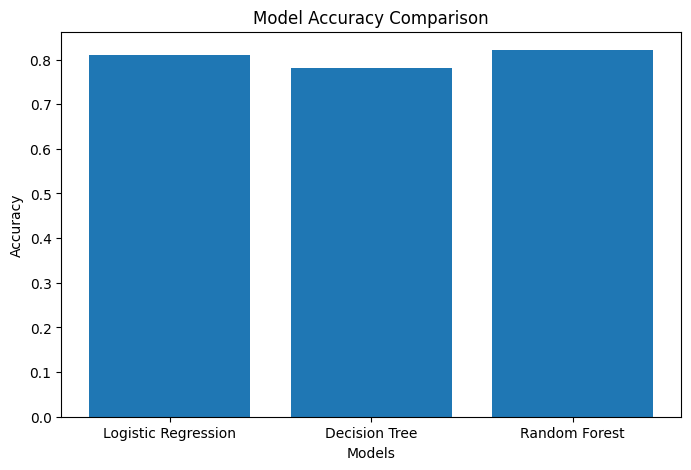

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

**Best Model**

In [48]:
best_model = comparison.iloc[0]

print("Best Performing Model")
print("----------------------")
print("Model :", best_model['Model'])
print("Accuracy :", round(best_model['Accuracy']*100,2), "%")

Best Performing Model
----------------------
Model : Logistic Regression
Accuracy : 81.01 %


# Model Comparison Analysis

Three machine learning models were trained and evaluated:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Among these models, the model with the highest accuracy was selected as the best-performing model for Titanic survival prediction.

This comparison helps in understanding how different algorithms perform on the same dataset and allows selection of the most suitable model.

# **Predictions**

In [27]:
y_pred = model.predict(
    X_test
)

# **Accuracy Score**

In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 81.01 %


# **Classification Report**

In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# **Confusion Matrix**

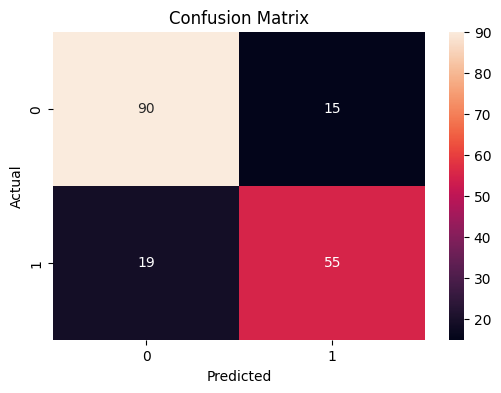

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **Feature Importance**

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

importance

,Feature,Coefficient
5,Fare,0.002534
2,Age,-0.030433
4,Parch,-0.111853
6,Embarked,-0.218777
3,SibSp,-0.293905
0,Pclass,-0.930680
1,Sex,-2.596994


# **Sample Prediction**

In [31]:
sample = [[
    3,
    1,
    25,
    0,
    0,
    7.25,
    2
]]

prediction = model.predict(
    sample
)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Did Not Survive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Business Insights

1. Female passengers had a higher survival rate.
2. First-class passengers were more likely to survive.
3. Higher fare passengers had better survival chances.
4. Passenger class and gender were strong survival indicators.
5. Age also influenced survival probability.

# Future Scope

- Hyperparameter Tuning
- Cross Validation
- Ensemble Learning
- Model Deployment using Streamlit
- Real-Time Prediction System

# Conclusion

The Titanic Survival Prediction project was successfully completed using Machine Learning techniques. Data preprocessing, EDA, visualization, feature engineering, model comparison, prediction, and evaluation were performed to understand the factors influencing passenger survival.